In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import lxml


Cargue los datos de incidentes viales reportados por C5 (Viales_2022_2024.csv en Github) y realice lo siguiente:

In [69]:
ruta ='https://raw.githubusercontent.com/jamc88/AD-MCMAI/refs/heads/main/Datos/Viales_2022_2024.csv'
df = pd.read_csv(ruta, chunksize=10_000)
df

In [70]:
for chunk in pd.read_csv(ruta, chunksize=10_000):
    print(chunk.columns)
    break

Index(['fecha_creacion', 'hora_creacion', 'tipo_incidente_c4', 'incidente_c4',
       'alcaldia_inicio', 'clas_con_f_alarma', 'tipo_entrada',
       'alcaldia_catalogo', 'colonia_catalogo', 'longitud', 'latitud'],
      dtype='object')


a) Obtenga un Dataframe con los tipos de incidentes y su frecuencia. Obtenga un gráfico que ilustre esto.

In [71]:
#a) Obtenga un Dataframe con los tipos de incidentes y su frecuencia
tot = pd.Series([], dtype='int64')

for piece in df:
    tot = tot.add(piece['tipo_incidente_c4'].value_counts(), fill_value=0)
    tot = tot.sort_values(ascending=False)

incidentes = pd.DataFrame(tot,columns=['Frecuencia'])
incidentes

,Frecuencia
tipo_incidente_c4,
Accidente,150097.0
Lesionado,17356.0
Cadáver,353.0
Detención ciudadana,120.0
Mi Calle,105.0
Sismo,36.0
Mi Taxi,20.0


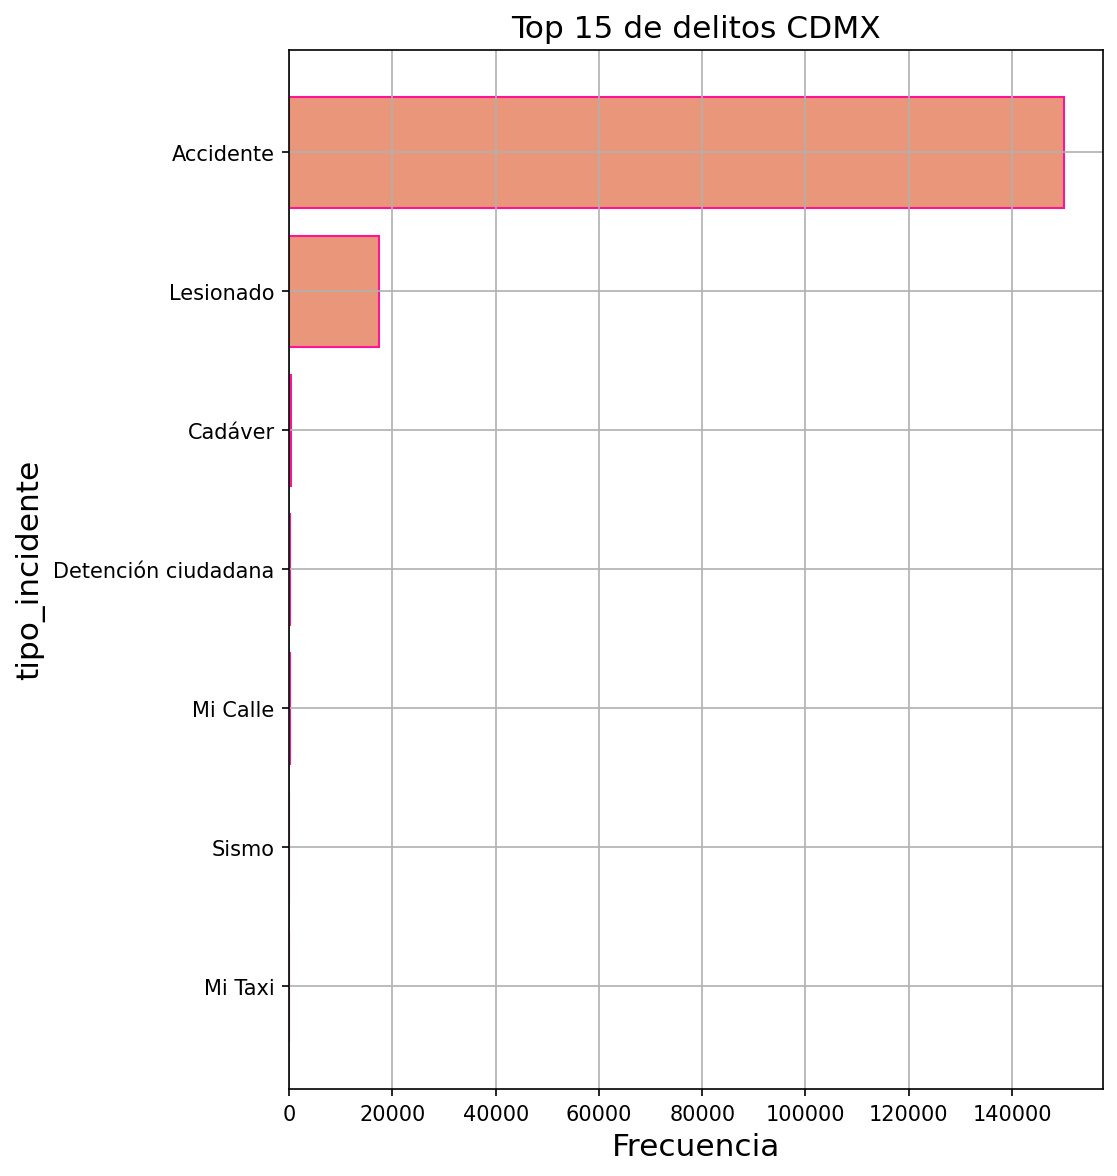

In [72]:
plt.figure(figsize=(7,9), dpi=150)
plt.barh(incidentes.index, incidentes['Frecuencia']
         ,facecolor='#E9967A', edgecolor='#FF1493')
plt.title('Top 15 de delitos CDMX', fontsize = 15)
plt.xlabel('Frecuencia', fontsize = 15)
plt.ylabel('tipo_incidente', fontsize = 15)
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

b) Obtenga un Dataframe con los incidentes y su frecuencia. Obtenga un gráfico que ilustre esto.

In [73]:
incidentes1 = piece.groupby('incidente_c4').size().reset_index(name='frecuencia_incidentes')
incidentes1 = incidentes1.sort_values(by='frecuencia_incidentes', ascending=False)
incidentes1

,incidente_c4,frecuencia_incidentes
4,Choque sin lesionados,3629
2,Choque con lesionados,2458
1,Atropellado,887
7,Motociclista,812
5,Ciclista,100
11,Volcadura,99
9,Persona atrapada / desbarrancada,51
10,Vehículo atrapadovarado,23
3,Choque con prensados,15
0,Accidente automovilístico,8


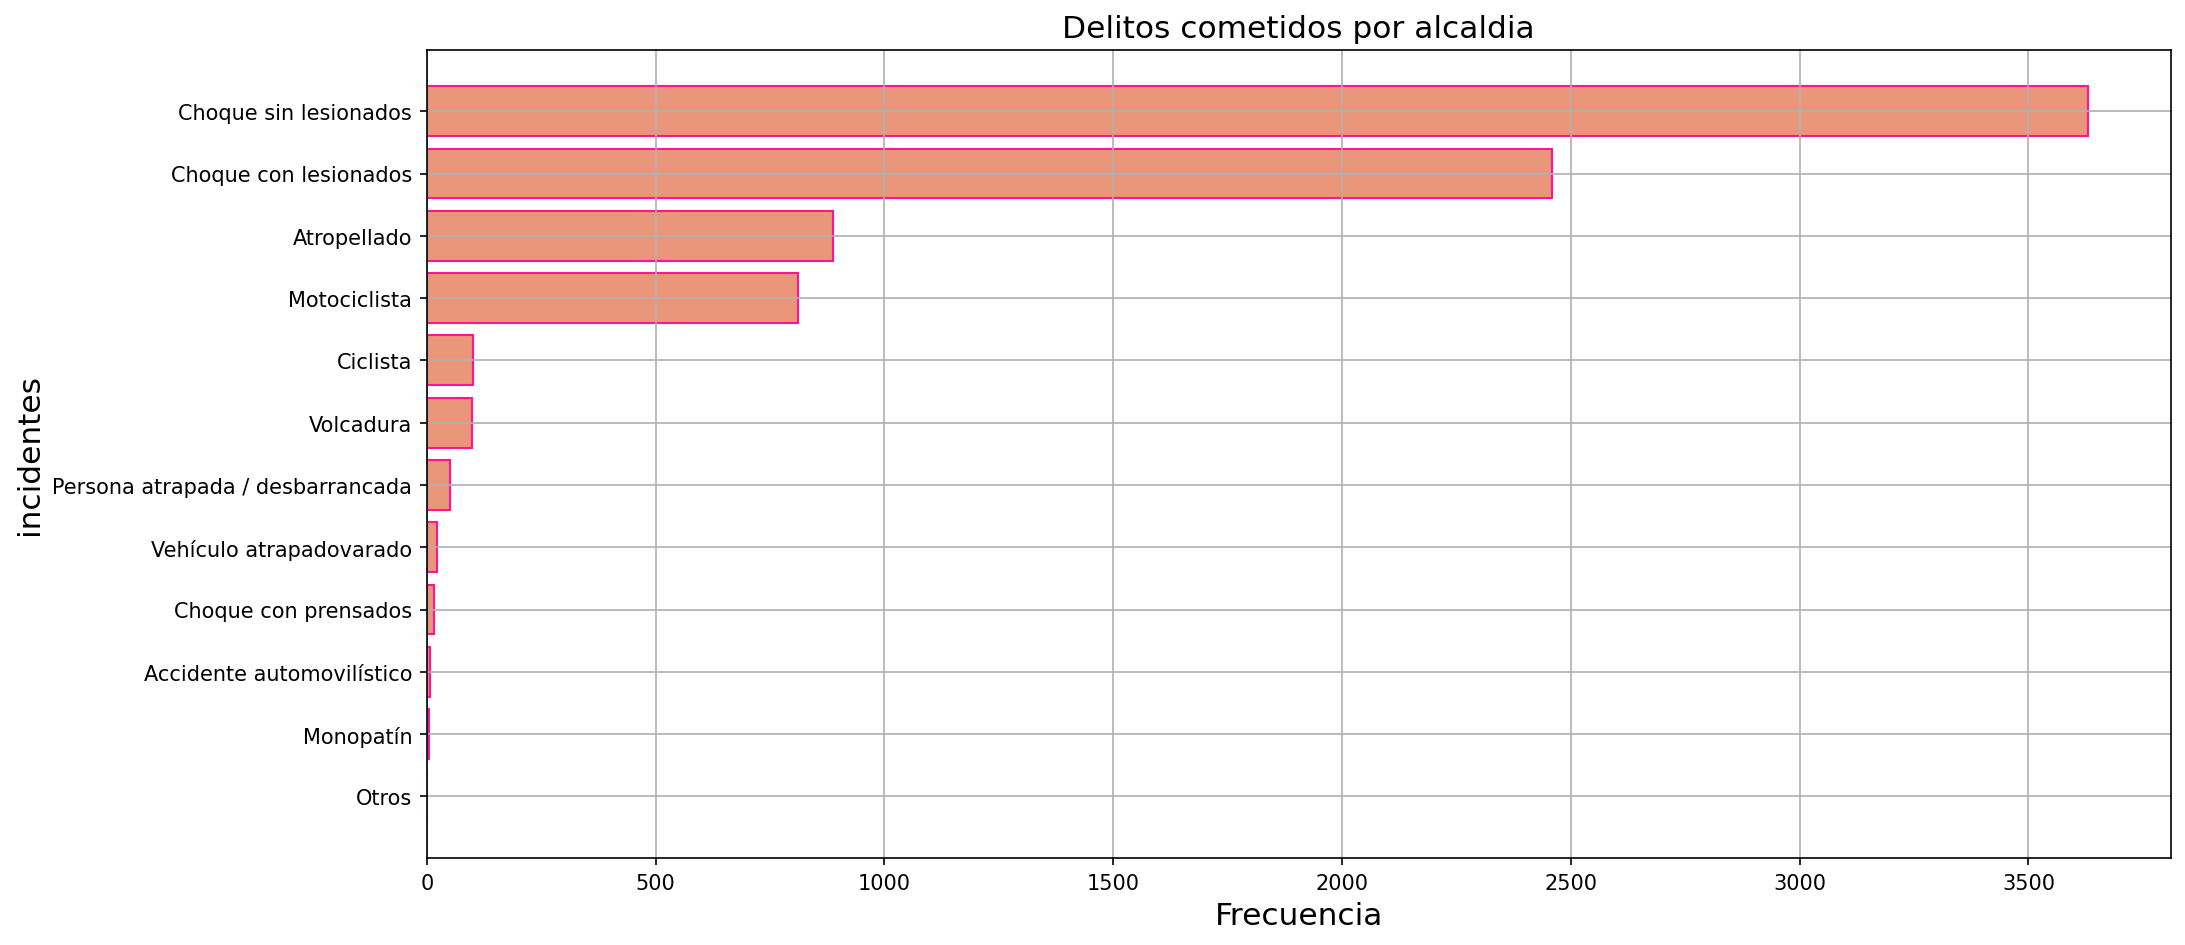

In [74]:
#grafica de Data Frame de incidentes_c4
plt.figure(figsize=(15,7), dpi=150)
plt.barh(incidentes1['incidente_c4'], incidentes1['frecuencia_incidentes']
         ,facecolor='#E9967A', edgecolor='#FF1493')
plt.title('Delitos cometidos por alcaldia', fontsize = 15)
plt.xlabel('Frecuencia', fontsize = 15)
plt.ylabel('incidentes', fontsize = 15)
plt.gca().invert_yaxis()
plt.grid(True)

c) Obtenga un gráfico de barras que iluste el número de incidentes por alcaldía (columna 'alcaldia_inicio')

In [75]:
#Obtenga un gráfico de barras que iluste el número de incidentes por alcaldía (columna 'alcaldia_inicio')
incidentes2 = piece.groupby('alcaldia_inicio').size().reset_index(name='frecuencia_incidentes')
incidentes2 = incidentes2.sort_values(by='frecuencia_incidentes', ascending=False)
incidentes2

,alcaldia_inicio,frecuencia_incidentes
8,IZTAPALAPA,1311
6,GUSTAVO A. MADERO,947
5,CUAUHTEMOC,829
14,VENUSTIANO CARRANZA,610
13,TLALPAN,598
3,COYOACAN,586
2,BENITO JUAREZ,558
0,ALVARO OBREGON,544
10,MIGUEL HIDALGO,480
7,IZTACALCO,373


In [76]:
conteo = piece.groupby(['alcaldia_inicio', 'incidente_c4']).size().reset_index(name='frecuencia_incidentes')
conteo = conteo.sort_values(by='frecuencia_incidentes', ascending=False)
conteo

,alcaldia_inicio,incidente_c4,frecuencia_incidentes
74,IZTAPALAPA,Choque sin lesionados,601
56,GUSTAVO A. MADERO,Choque sin lesionados,419
72,IZTAPALAPA,Choque con lesionados,399
46,CUAUHTEMOC,Choque sin lesionados,318
54,GUSTAVO A. MADERO,Choque con lesionados,299
...,...,...,...
125,VENUSTIANO CARRANZA,Persona atrapada / desbarrancada,1
123,VENUSTIANO CARRANZA,Monopatín,1
134,XOCHIMILCO,Otros,1
135,XOCHIMILCO,Persona atrapada / desbarrancada,1


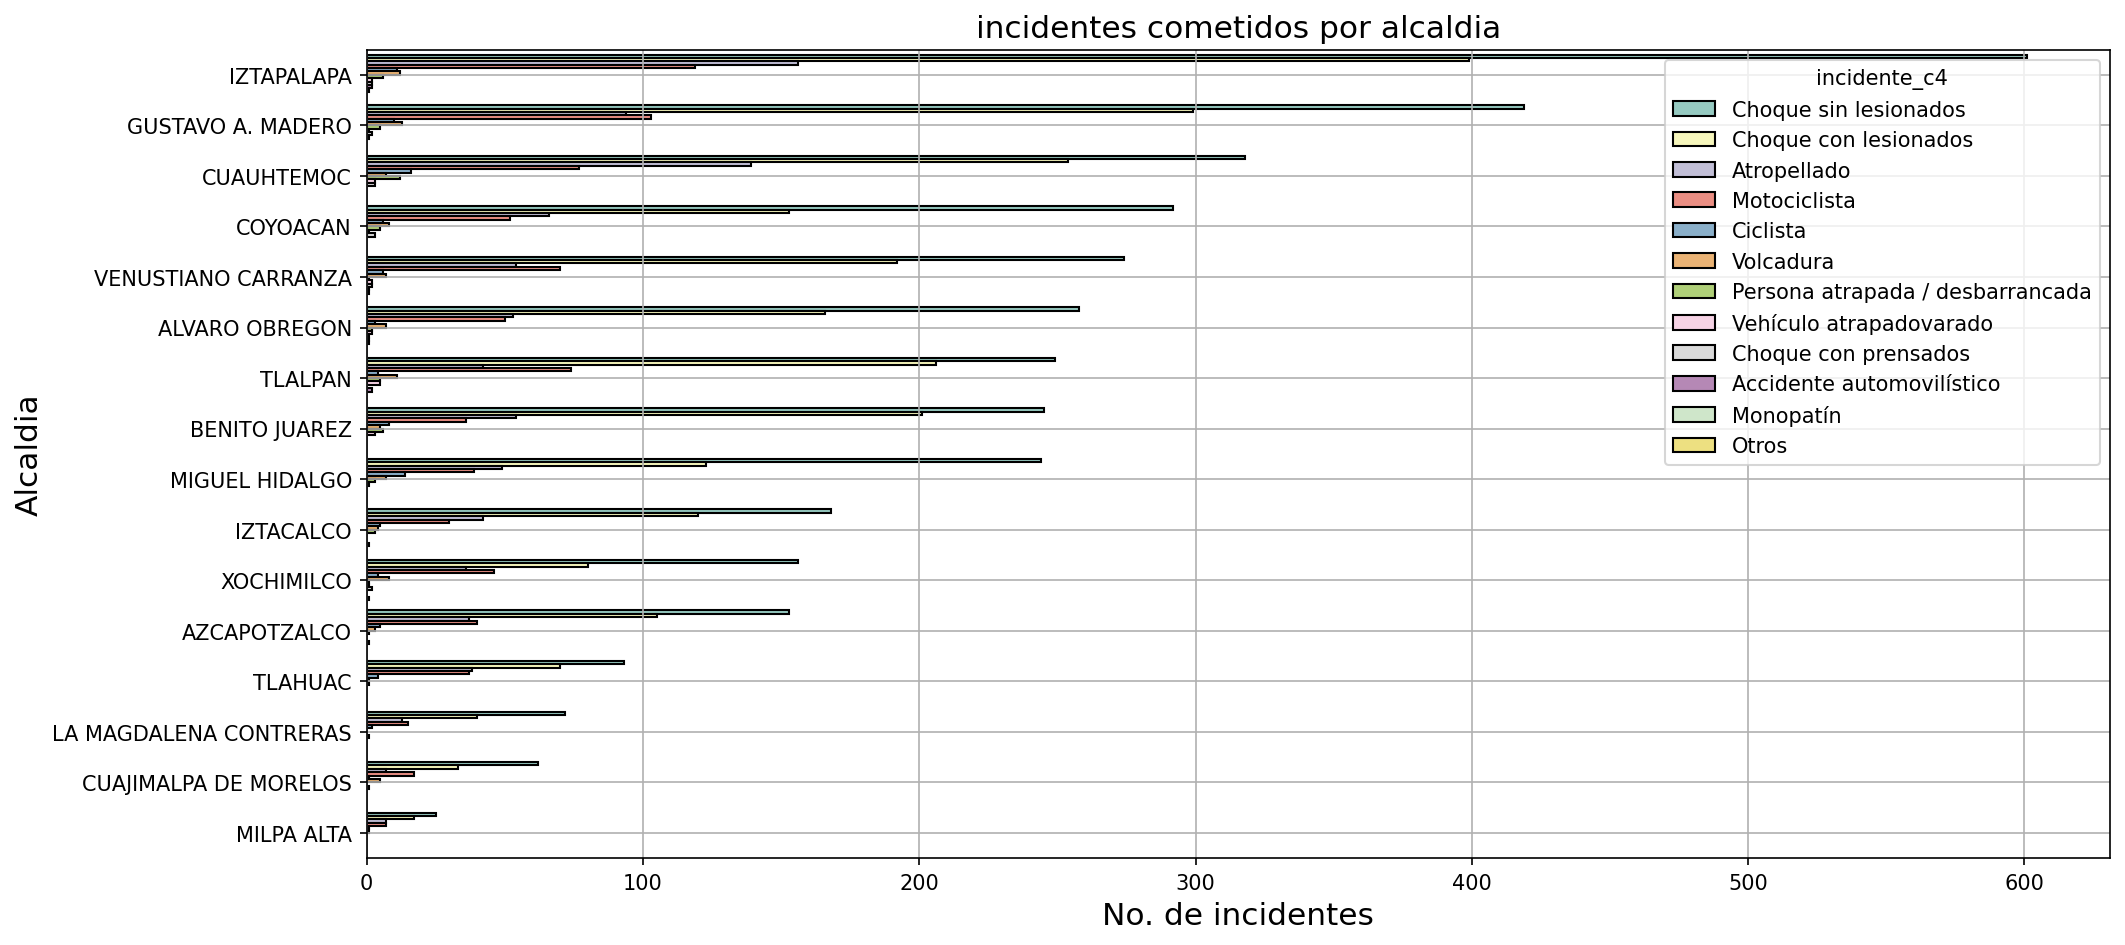

In [77]:
#Obtenga un gráfico de barras que iluste el número de incidentes por alcaldía (columna 'alcaldia_inicio')
plt.figure(figsize=(15,7), dpi=150)
sns.barplot(data=conteo, y='alcaldia_inicio', x='frecuencia_incidentes',hue='incidente_c4',palette='Set3',edgecolor='black')
plt.title('incidentes cometidos por alcaldia', fontsize = 15)
plt.xlabel('No. de incidentes', fontsize = 15)
plt.ylabel('Alcaldia', fontsize = 15)
#plt.gca().invert_yaxis()
plt.grid(True)



> d) Obtenga una serie temporal con el número de atropellados por semana y grafique la serie



In [95]:
ruta ='https://raw.githubusercontent.com/jamc88/AD-MCMAI/refs/heads/main/Datos/Viales_2022_2024.csv'
df_atropellados = pd.read_csv(ruta)
df_atropellados = df_atropellados[df_atropellados['incidente_c4'] == 'Atropellado']

In [96]:
df_atropellados['fecha_creacion'] = pd.to_datetime(df_atropellados['fecha_creacion'])
df_atropellados = df_atropellados.set_index('fecha_creacion')
atropellados_sem= df_atropellados.resample('W').size()
atropellados_sem

,0
fecha_creacion,
2022-01-02,29
2022-01-09,134
2022-01-16,99
2022-01-23,115
2022-01-30,114
...,...
2024-02-04,169
2024-02-11,140
2024-02-18,168


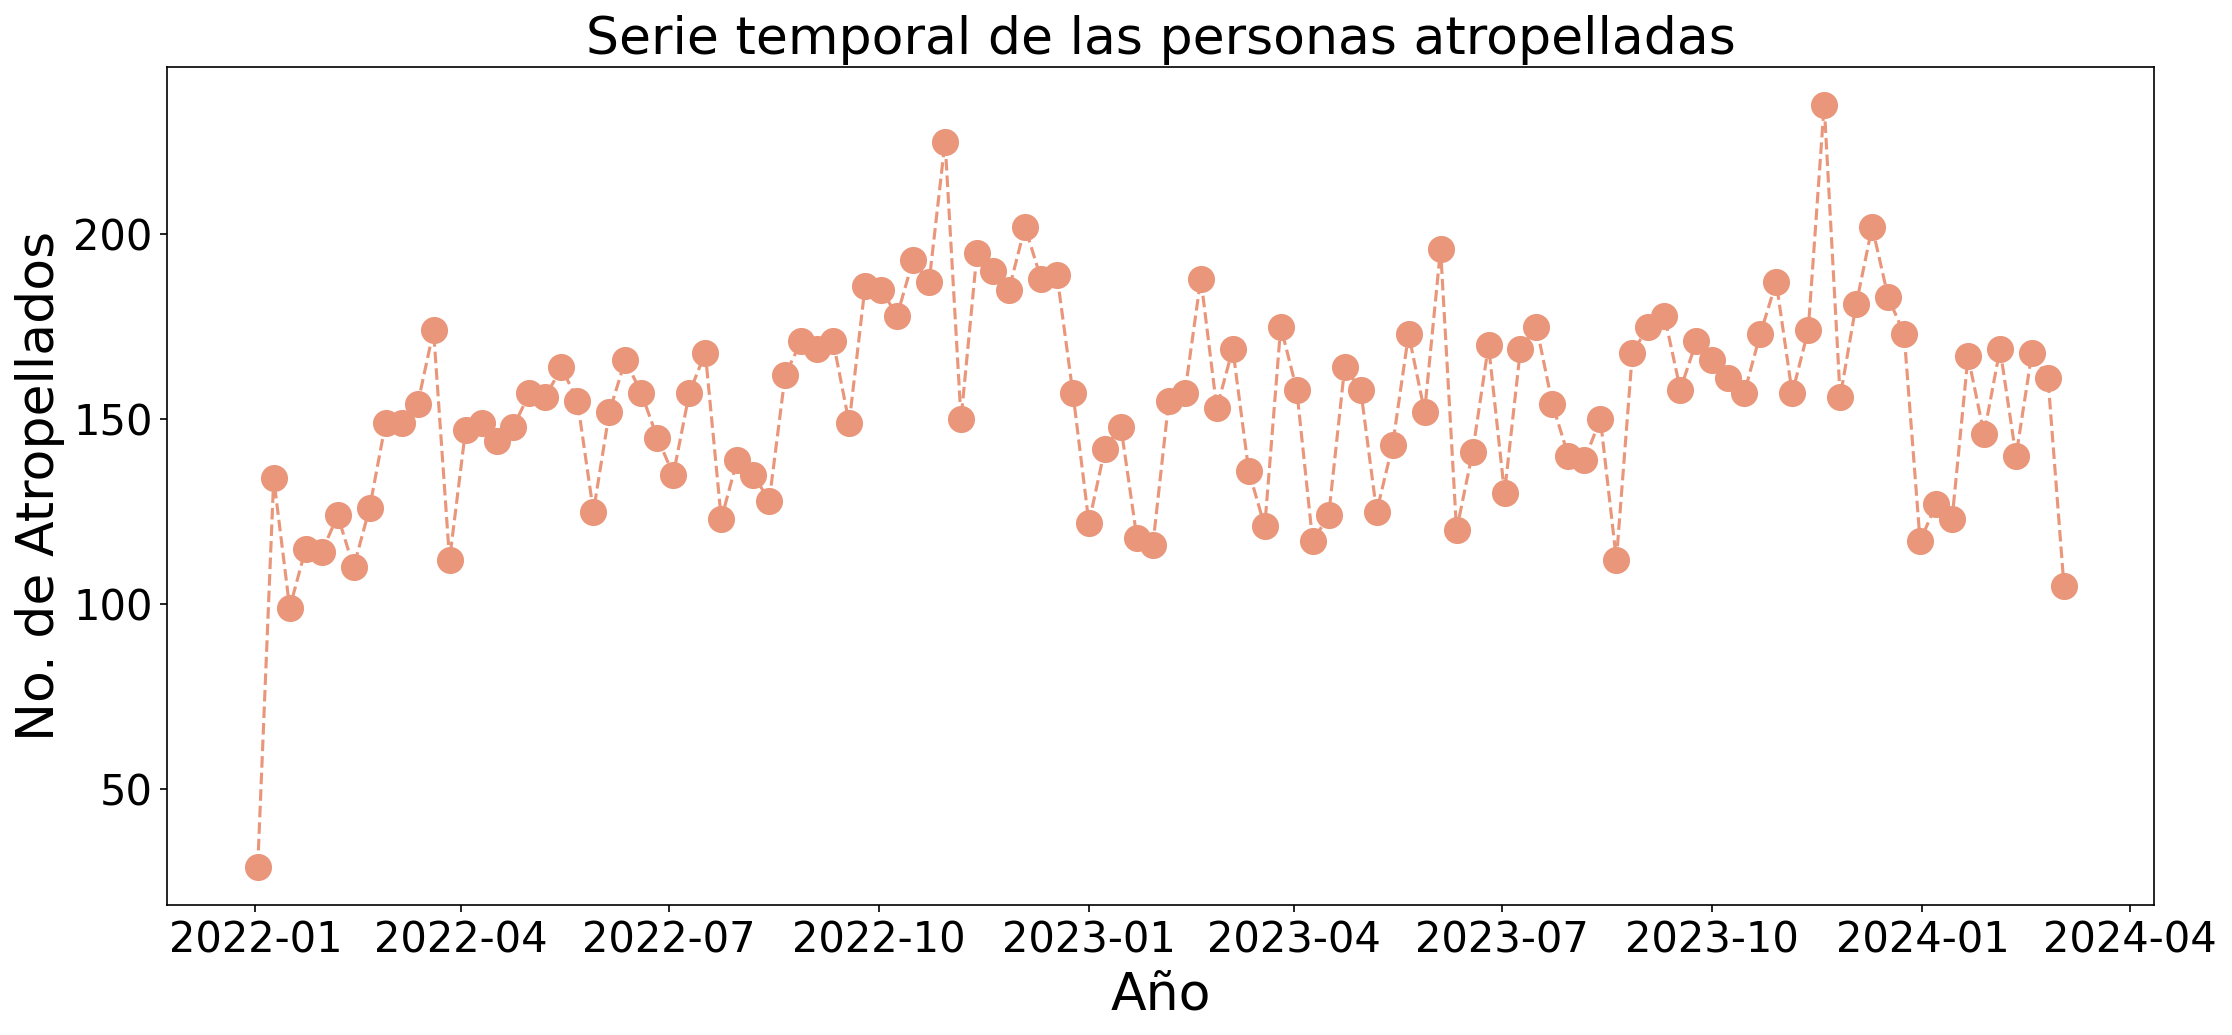

In [97]:
#grafica de serie temporal de los atropellados
plt.figure(figsize=(15,7), dpi=150)
plt.plot(atropellados_sem.index, atropellados_sem.values, color='#E9967A',linestyle='dashed', marker= 'o', markersize=12)
plt.title('Serie temporal de las personas atropelladas', fontdict={'fontsize':25})
plt.xlabel('Año', fontdict={'fontsize':25})
plt.ylabel('No. de Atropellados', fontdict={'fontsize':25})
plt.tick_params(labelsize=20)
plt.tight_layout()
plt.show()


e) Obtenga un mapa de calor (HeatMap) que muestre la ubicación geográfica de los reportes de personas atropelladas, utilizando las coordenadas de latitud y longitud asociadas a cada incidente.

In [98]:
import folium

In [99]:
from folium.plugins import HeatMap
import folium


m = folium.Map(location=[19.4, -99.1],
               zoom_start=11, tiles="Cartodb Positron")

HeatMap(df_atropellados[["latitud", "longitud"]].dropna(), radius=7,
        blur=1, min_opacity=0.2).add_to(m)
m

Ejercicio 2. (50 puntos)
Extraiga las tabla de "Terremotos de mayor magnitud" del siguiente enlace:

https://es.wikipedia.org/wiki/Anexo:Terremotos_de_mayor_magnitud

y realice lo siguiente:

a) Obtenga el siguiente Dataframe.

In [34]:
ruta ='https://es.wikipedia.org/wiki/Anexo:Terremotos_de_mayor_magnitud'
df1 = pd.read_html(ruta)
df1

[                                                       Visualiza un mapa con todas las coordenadas
   Sitúa todas las coordenadas utilizando OpenStreetMap Sitúa hasta 200 coordenadas utilizando Bing
 0       Exporta todas las coordenadas en formato KML                                              
 1    Exporta todas las coordenadas en formato GeoRSS                                              
 2       Exporta todas las coordenadas en formato GPX                                              
 3  Sitúa en el mapa todas las coordenadas microfo...                                              ,
     N.º                 Fecha y hora UTC          Magnitud  \
 0     1        22 de mayo de 1960, 15:11    9,5 MW[2]​[3]​   
 1     2   26 de diciembre de 2004, 00:58        9,3 MW[5]​   
 2     2       28 de marzo de 1964, 03:36    9,2 MW[3]​[7]​   
 3     4       11 de marzo de 2011, 05:46        9,1 MW[9]​   
 4     4    4 de noviembre de 1952, 16:58  9,0 MW[11]​[12]​   
 5     4      13 de a

In [35]:
len(df1)

3

In [36]:
 df_datos= df1[1]

In [37]:
#hay que quitar la fila 26
df_datos.drop(26, inplace=True)

In [20]:
df_datos

,N.º,Fecha y hora UTC,Magnitud,Nombre,País,Lugar y coordenadas,Muertes
0,1,"22 de mayo de 1960, 15:11","9,5 MW[2]​[3]​",Terremoto de Valdivia de 1960[4]​,Chile,"Valdivia, Región de los Ríos38°14′24″S 73°3′0″...",1655 a 2000
1,2,"26 de diciembre de 2004, 00:58","9,3 MW[5]​",Terremoto del océano Índico de 2004[6]​,Indonesia,Frente al norte de la isla de Sumatra,230 270
2,2,"28 de marzo de 1964, 03:36","9,2 MW[3]​[7]​",Terremoto de Alaska de 1964[7]​[8]​,Estados Unidos,"Anchorage, Alaska 61°N 148°O﻿ / ﻿61, -148",128
3,4,"11 de marzo de 2011, 05:46","9,1 MW[9]​",Terremoto y maremoto de Japón de 2011[10]​,Japón,"Costa Este de la Región de Tōhoku, Honshū 38°1...",15 897
4,4,"4 de noviembre de 1952, 16:58","9,0 MW[11]​[12]​",Terremoto de Kamchatka de 1952[11]​[13]​[14]​,Unión Soviética (actual Rusia),Península de Kamchatka 52°48′N 159°30′E﻿ / ﻿52...,2366
5,4,"13 de agosto de 1868, 21:30","9,0 MW[15]​",Terremoto de Arica de 1868[15]​[16]​,Perú (actual Chile),"Arica 18°36′S 71°0′O﻿ / ﻿-18.600, -71.000",693
6,4,"28 de octubre de 1746, 22:30","9,0 MW",Terremoto de Lima de 1746,"Virreinato del Perú, parte del Imperio español...",Lima y Callao 11°21′00″S 77°16′48″O﻿ / ﻿-11.35...,15 000 a 20 000
7,4,"26 de enero de 1700, 21:30","9,0 MW",Terremoto de Cascadia de 1700,"Noroeste del Pacífico, parte del Imperio britá...","California, Oregón, Washington y Columbia Brit...",Sin datos
8,9,"27 de febrero de 2010, 03:34","8,8 MW",Terremoto de Chile de 2010[17]​[18]​[19]​[20]​,Chile,"Cobquecura, Región del Biobío (actual Ñuble) 3...",525
9,9,"31 de enero de 1906, 15:36","8,8 MW[21]​",Terremoto de Ecuador y Colombia de 1906[22]​,Ecuador Colombia,Frente a las costas de Esmeraldas 1°0′N 81°30′...,1500


In [38]:
df_datos.drop(columns='N.º', inplace=True)


In [39]:
df_datos

,Fecha y hora UTC,Magnitud,Nombre,País,Lugar y coordenadas,Muertes
0,"22 de mayo de 1960, 15:11","9,5 MW[2]​[3]​",Terremoto de Valdivia de 1960[4]​,Chile,"Valdivia, Región de los Ríos38°14′24″S 73°3′0″...",1655 a 2000
1,"26 de diciembre de 2004, 00:58","9,3 MW[5]​",Terremoto del océano Índico de 2004[6]​,Indonesia,Frente al norte de la isla de Sumatra,230 270
2,"28 de marzo de 1964, 03:36","9,2 MW[3]​[7]​",Terremoto de Alaska de 1964[7]​[8]​,Estados Unidos,"Anchorage, Alaska 61°N 148°O﻿ / ﻿61, -148",128
3,"11 de marzo de 2011, 05:46","9,1 MW[9]​",Terremoto y maremoto de Japón de 2011[10]​,Japón,"Costa Este de la Región de Tōhoku, Honshū 38°1...",15 897
4,"4 de noviembre de 1952, 16:58","9,0 MW[11]​[12]​",Terremoto de Kamchatka de 1952[11]​[13]​[14]​,Unión Soviética (actual Rusia),Península de Kamchatka 52°48′N 159°30′E﻿ / ﻿52...,2366
5,"13 de agosto de 1868, 21:30","9,0 MW[15]​",Terremoto de Arica de 1868[15]​[16]​,Perú (actual Chile),"Arica 18°36′S 71°0′O﻿ / ﻿-18.600, -71.000",693
6,"28 de octubre de 1746, 22:30","9,0 MW",Terremoto de Lima de 1746,"Virreinato del Perú, parte del Imperio español...",Lima y Callao 11°21′00″S 77°16′48″O﻿ / ﻿-11.35...,15 000 a 20 000
7,"26 de enero de 1700, 21:30","9,0 MW",Terremoto de Cascadia de 1700,"Noroeste del Pacífico, parte del Imperio britá...","California, Oregón, Washington y Columbia Brit...",Sin datos
8,"27 de febrero de 2010, 03:34","8,8 MW",Terremoto de Chile de 2010[17]​[18]​[19]​[20]​,Chile,"Cobquecura, Región del Biobío (actual Ñuble) 3...",525
9,"31 de enero de 1906, 15:36","8,8 MW[21]​",Terremoto de Ecuador y Colombia de 1906[22]​,Ecuador Colombia,Frente a las costas de Esmeraldas 1°0′N 81°30′...,1500


In [40]:
#reemplazar datos en la fila 16
df_datos.loc[17, 'Fecha y hora UTC']


'15 de agosto de 1950'

In [41]:
df_datos.loc[17, 'Fecha y hora UTC'] = df_datos.loc[17, 'Fecha y hora UTC'].replace('15 de agosto de 1950', '15 de agosto de 1950 00:00')

In [42]:
df_datos.loc[17, 'Fecha y hora UTC']

'15 de agosto de 1950 00:00'

In [43]:
df_datos[['fecha', 'hora']] = df_datos['Fecha y hora UTC'].str.split(',', n=1, expand=True)

In [44]:
df_datos['hora'] = df_datos['hora'].fillna('00:00')
df_datos['hora'] = df_datos['hora'].str.strip()
df_datos['hora'] = df_datos['hora'].replace('','00:00')

In [45]:
df_datos

,Fecha y hora UTC,Magnitud,Nombre,País,Lugar y coordenadas,Muertes,fecha,hora
0,"22 de mayo de 1960, 15:11","9,5 MW[2]​[3]​",Terremoto de Valdivia de 1960[4]​,Chile,"Valdivia, Región de los Ríos38°14′24″S 73°3′0″...",1655 a 2000,22 de mayo de 1960,15:11
1,"26 de diciembre de 2004, 00:58","9,3 MW[5]​",Terremoto del océano Índico de 2004[6]​,Indonesia,Frente al norte de la isla de Sumatra,230 270,26 de diciembre de 2004,00:58
2,"28 de marzo de 1964, 03:36","9,2 MW[3]​[7]​",Terremoto de Alaska de 1964[7]​[8]​,Estados Unidos,"Anchorage, Alaska 61°N 148°O﻿ / ﻿61, -148",128,28 de marzo de 1964,03:36
3,"11 de marzo de 2011, 05:46","9,1 MW[9]​",Terremoto y maremoto de Japón de 2011[10]​,Japón,"Costa Este de la Región de Tōhoku, Honshū 38°1...",15 897,11 de marzo de 2011,05:46
4,"4 de noviembre de 1952, 16:58","9,0 MW[11]​[12]​",Terremoto de Kamchatka de 1952[11]​[13]​[14]​,Unión Soviética (actual Rusia),Península de Kamchatka 52°48′N 159°30′E﻿ / ﻿52...,2366,4 de noviembre de 1952,16:58
5,"13 de agosto de 1868, 21:30","9,0 MW[15]​",Terremoto de Arica de 1868[15]​[16]​,Perú (actual Chile),"Arica 18°36′S 71°0′O﻿ / ﻿-18.600, -71.000",693,13 de agosto de 1868,21:30
6,"28 de octubre de 1746, 22:30","9,0 MW",Terremoto de Lima de 1746,"Virreinato del Perú, parte del Imperio español...",Lima y Callao 11°21′00″S 77°16′48″O﻿ / ﻿-11.35...,15 000 a 20 000,28 de octubre de 1746,22:30
7,"26 de enero de 1700, 21:30","9,0 MW",Terremoto de Cascadia de 1700,"Noroeste del Pacífico, parte del Imperio britá...","California, Oregón, Washington y Columbia Brit...",Sin datos,26 de enero de 1700,21:30
8,"27 de febrero de 2010, 03:34","8,8 MW",Terremoto de Chile de 2010[17]​[18]​[19]​[20]​,Chile,"Cobquecura, Región del Biobío (actual Ñuble) 3...",525,27 de febrero de 2010,03:34
9,"31 de enero de 1906, 15:36","8,8 MW[21]​",Terremoto de Ecuador y Colombia de 1906[22]​,Ecuador Colombia,Frente a las costas de Esmeraldas 1°0′N 81°30′...,1500,31 de enero de 1906,15:36


In [46]:
df_datos['año'] = df_datos['fecha'].str.extract(r'(\d{4})').astype(int)

In [47]:
meses = {'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4,'mayo': 5, 'junio': 6, 'julio': 7, 'agosto': 8,
    'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12}

In [48]:
df_datos['mes']=df_datos['fecha'].str.extract(r'de (\w+) de')
df_datos['mes'] = df_datos['mes'].map(meses)

In [49]:
df_datos['dia'] = df_datos['fecha'].str.extract(r'(\d{1,2})').astype(int)

In [57]:
df_datos['Magnitud_lim']= df_datos['Magnitud']\
      .str.replace(r'\[.*?\]', '', regex=True)\
      .str.replace(r'[^\d,\.]', '', regex=True)\
      .str.replace(',', '.')\
      .astype(float)

In [58]:
df_final =df_datos[['año','mes','dia','hora','Magnitud_lim', 'Muertes', 'País']]
df_final.columns = ['año','mes','dia','hora','Magnitud','Muertes','País']
df_final

,año,mes,dia,hora,Magnitud,Muertes,País
0,1960,5,22,15:11,9.5,1655 a 2000,Chile
1,2004,12,26,00:58,9.3,230 270,Indonesia
2,1964,3,28,03:36,9.2,128,Estados Unidos
3,2011,3,11,05:46,9.1,15 897,Japón
4,1952,11,4,16:58,9.0,2366,Unión Soviética (actual Rusia)
5,1868,8,13,21:30,9.0,693,Perú (actual Chile)
6,1746,10,28,22:30,9.0,15 000 a 20 000,"Virreinato del Perú, parte del Imperio español..."
7,1700,1,26,21:30,9.0,Sin datos,"Noroeste del Pacífico, parte del Imperio britá..."
8,2010,2,27,03:34,8.8,525,Chile
9,1906,1,31,15:36,8.8,1500,Ecuador Colombia


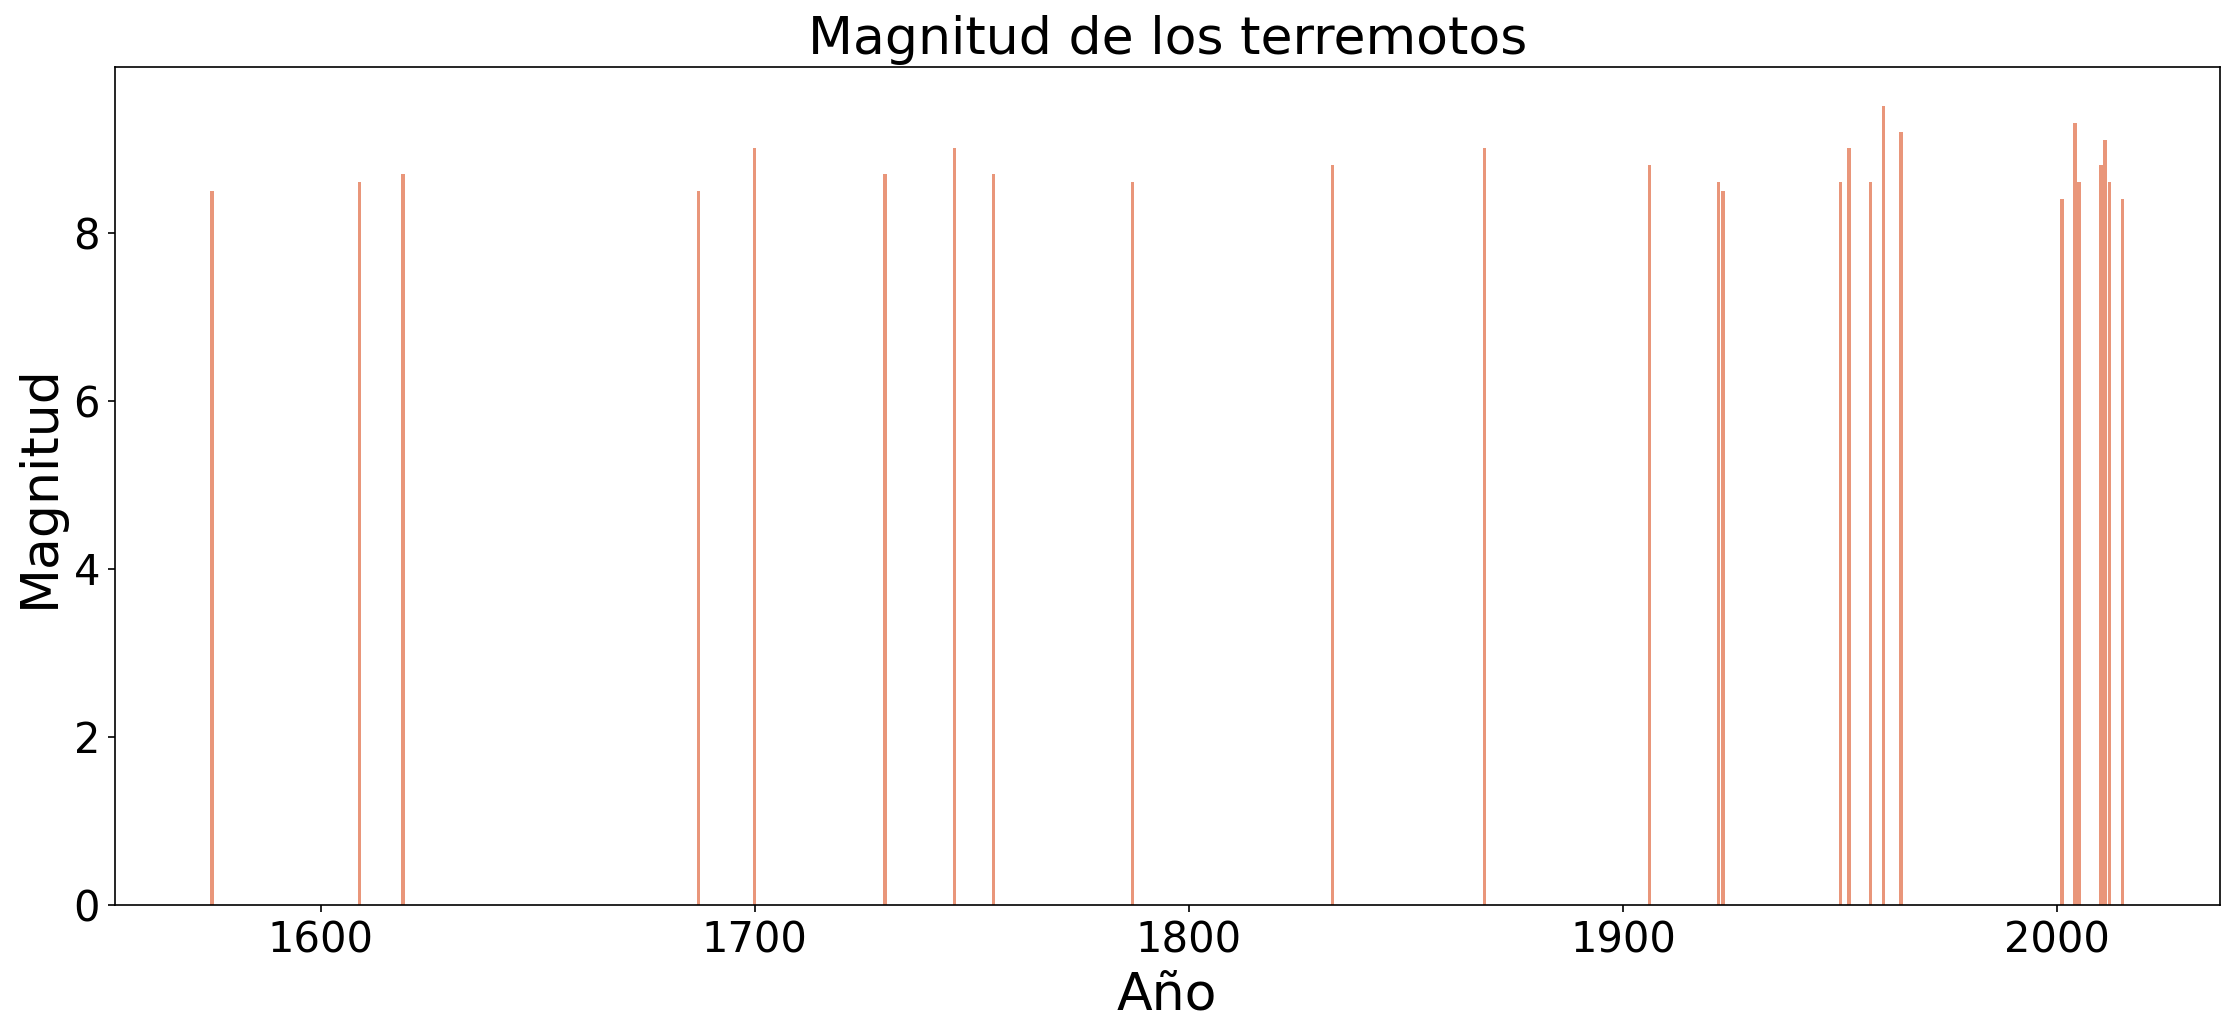

In [60]:
plt.figure(figsize=(15,7), dpi=150)
plt.bar(df_final['año'], df_final['Magnitud'], color='#E9967A')
plt.xlabel('Año', fontdict={'fontsize':25})
plt.ylabel('Magnitud', fontdict={'fontsize':25})
plt.title('Magnitud de los terremotos', fontdict={'fontsize':25})
plt.tick_params(labelsize=20)
plt.tight_layout()
plt.show()


c) ¿Cuándo y dónde ocurrió el terremoto de mayor magnitud en la historia?

In [61]:
idmax = df_final['Magnitud'].idxmax()
terremoto_max = df_final.loc[idmax]


In [62]:
idmax

0

In [63]:
terremoto_max

,0
año,1960
mes,5
dia,22
hora,15:11
Magnitud,9.5
Muertes,1655 a 2000
País,Chile
